In [29]:
from DataLoader import DataLoader
from tara_preprocessing import get_just_ecog_data,get_electrode_normalized_loc
from tara_preprocessing import remove_duplicates, preprocessing,apply_car_function
from noah_production_funcs import get_1_patient_locations
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm

In [30]:
from torch_geometric.datasets import TUDataset
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool,global_add_pool

In [31]:
data_root = Path("../faces_basic/data")
registered_dir = Path("/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)
print('Downloaded data')
ecogs_no_dups,xyz_no_dups = remove_duplicates(ecogs,xyz)
print('Removed duplicate electrodes')
xyz_clean, ecogs_cleaned = preprocessing(ecogs_no_dups,xyz_no_dups,notch_size=.05)
print("Done Preprocessing")

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

In [4]:
win_size = 800
safety_size = 200
x = 0
k = 10 #number of neareest neighbors for making the graph
max_data_points = 10000000
num_epochs      = 5      
factor_held_out = 3 #ie number held out is num_nodes / factor_held_out, rounded to nearest int, so bigger factor_held_out means less held out

In [5]:

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels,num_features_per_node,output_size):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(num_features_per_node, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, output_size)

    def forward(self, x, edge_index,weights,batch=None):
        x = self.conv1(x, edge_index,weights)
        x = self.conv2(x, edge_index,weights)
        x = self.conv3(x, edge_index,weights)
        x = global_add_pool(x, batch).squeeze()
        x = F.relu(self.lin(x))
        
        return x
# hidden_channels: is the size of the input/output of hidden layers
model = GCN(hidden_channels=64,num_features_per_node=win_size,output_size=win_size)

In [11]:
from torch_geometric_temporal.nn.recurrent import DCRNN

class DCRNNModel(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, K=2):
        super(DCRNNModel, self).__init__()
        self.dcrnn_encoder = DCRNN(in_channels=in_channels,      # 4: signal + xyz
                                   out_channels=hidden_channels,
                                   K=K)
        self.dcrnn_decoder = DCRNN(in_channels=4,                # 1 signal + 3 xyz
                                   out_channels=hidden_channels,
                                   K=K)
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_weight, locs):
        # in the forward pass, pass None instead of edge_weight:

        # Encode
        h = None
        for t in range(x.shape[0]):
            h = self.dcrnn_encoder(x[t], edge_index, None, H=h)  # [nodes, hidden]

        # Decode: predict each future timestep, keeping locations attached
        preds = []
        decoder_signal = torch.zeros(x.shape[1], 1, device=x.device)   # [nodes, 1] start token
        for t in range(x.shape[0]):
            decoder_input = torch.cat([decoder_signal, locs], dim=-1)   # [nodes, 4]
            h = self.dcrnn_decoder(decoder_input, edge_index, None, H=h)
            out = self.lin(h)                                            # [nodes, 1]
            preds.append(out)
            decoder_signal = out                                         # feed prediction back in

        return torch.stack(preds, dim=-1).squeeze(1)                    # [nodes, win_size]


model = DCRNNModel(in_channels=4,
                   hidden_channels=64,
                   out_channels=win_size,
                   K=2)

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_func = torch.nn.MSELoss()

In [8]:
from torch_geometric.utils import to_undirected

loss_list = []
for pat_index in range(len(ecogs_cleaned)):
    pat_locs = get_1_patient_locations(pat_index, ecogs_cleaned, xyz_clean)
    desired_iter_per_node = ecogs_cleaned[pat_index].shape[0] / win_size - safety_size
    pat_num_nodes = ecogs_cleaned[pat_index].shape[1]
    list_held = np.random.randint(low=0, high=pat_num_nodes - 1,
                                  size=int(pat_num_nodes / factor_held_out))
    loader = DataLoader(limit=max_data_points,
                        patient=pat_index,
                        window_size=win_size,
                        ecogs=ecogs_cleaned,
                        desired_node_iters=desired_iter_per_node,
                        elecs_to_hold=list_held,
                        xyz=pat_locs,
                        k=k)
    for point in loader:
        edges = torch.tensor(point['edges'], dtype=torch.long)
        if edges.shape[0] != 2:
            edges = edges.T
        edge_weights = torch.tensor(point['weights'], dtype=torch.float32)

        # Build unflattened x: [win_size, nodes, 4]
        features = torch.tensor(point['features'], dtype=torch.float32)  # [nodes, win_size]
        locs = torch.tensor(point['locs'], dtype=torch.float32)          # [nodes, 3]
        x_signal = features.T.unsqueeze(-1)                              # [win_size, nodes, 1]
        locs_expanded = locs.unsqueeze(0).expand(win_size, -1, -1)       # [win_size, nodes, 3]
        x = torch.cat([x_signal, locs_expanded], dim=-1)                 # [win_size, nodes, 4]

        y = torch.tensor(point['target'], dtype=torch.float32)           # [win_size]
        y = y.unsqueeze(0).repeat(len(list_held), 1)                     # [num_held, win_size]

        edges, edge_weights = to_undirected(edges, edge_weights, num_nodes=features.shape[0])

        optimizer.zero_grad()
        y_pred = model(x, edges, edge_weights, locs)                           # [nodes, win_size]
        y_pred_held = y_pred[list_held]                                  # [num_held, win_size]
        loss = loss_func(y_pred_held, y)
        loss.backward()
        loss_list.append(loss.detach().item())
        optimizer.step()


RuntimeError: Number of dimensions of repeat dims can not be smaller than number of dimensions of tensor

In [ ]:
loss_list = []
for pat_index in range(len(ecogs_cleaned)): #for each patient
    pat_locs = get_1_patient_locations(pat_index,ecogs_cleaned,xyz_clean)
    desired_iter_per_node = ecogs_cleaned[pat_index].shape[0]/win_size - safety_size #timeseries length over window size with a little bit of wiggle room for safety
    pat_num_nodes = ecogs_cleaned[pat_index].shape[1]

    list_held = np.random.randint(low=0,high=pat_num_nodes-1,size=int(pat_num_nodes/factor_held_out))
    #print(list_held)
    loader = DataLoader(limit=max_data_points,
                        patient=pat_index,
                        window_size=800,
                        ecogs=ecogs_cleaned,
                        desired_node_iters=desired_iter_per_node,
                        elecs_to_hold=list_held,
                        xyz=pat_locs,
                        k=k)
    for point in loader:
        # point is a dictionary with the following entires:
        # point['edges'] returns the edges matrix
        # point['weights'] returns the edge weights matrix
        # point['features'] returns the matrix of node features
        # point['targets'] returns the held out electrode window to compare to
        ########### PUT YOUR TRAINING HERE ###########
        edges = torch.tensor(point['edges'].T)
        edge_weights = torch.tensor(point['weights'],dtype=torch.float32)
        features = torch.tensor(point['features'],dtype=torch.float32)
        y = torch.tensor(point['target'],dtype=torch.float32)
        optimizer.zero_grad()
        y_pred = model(features,edges,edge_weights)
        loss = loss_func(y_pred,y)
        loss.backward()
        loss_list.append(loss.detach())
        optimizer.step()  
        


        
        

In [32]:
from torch_geometric.utils import to_dense_adj, dense_to_sparse

class FixedDConv(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K):
        super().__init__()
        self.K = K
        self.weight = torch.nn.Parameter(
            torch.FloatTensor(2, K, in_channels, out_channels)
        )
        torch.nn.init.xavier_uniform_(self.weight[0])
        torch.nn.init.xavier_uniform_(self.weight[1])

    def forward(self, X, edge_index, edge_weight=None):
        adj = to_dense_adj(edge_index, edge_attr=edge_weight).squeeze(0)  # [N, N]
        N   = adj.shape[0]

        deg_out = adj.sum(dim=1).clamp(min=1)           # [N] row sum
        deg_in  = adj.sum(dim=0).clamp(min=1)           # [N] col sum
        deg_out_inv = 1.0 / deg_out                     # [N]
        deg_in_inv  = 1.0 / deg_in                      # [N]

        # normalized adjacency: D_out^-1 * A and A * D_in^-1
        adj_out = deg_out_inv.unsqueeze(1) * adj        # [N, N]
        adj_in  = adj * deg_in_inv.unsqueeze(0)         # [N, N]

        # Chebyshev diffusion
        Tx_0 = X
        H = torch.matmul(Tx_0, self.weight[0][0]) + \
            torch.matmul(Tx_0, self.weight[1][0])

        if self.K > 1:
            Tx_1_o = torch.matmul(adj_out, X)           # [N, in]
            Tx_1_i = torch.matmul(adj_in.T, X)          # [N, in]
            H = H + torch.matmul(Tx_1_o, self.weight[0][1]) + \
                    torch.matmul(Tx_1_i, self.weight[1][1])

        for k in range(2, self.K):
            Tx_2_o = 2 * torch.matmul(adj_out, Tx_1_o) - Tx_0
            Tx_2_i = 2 * torch.matmul(adj_in.T, Tx_1_i) - Tx_0
            H = H + torch.matmul(Tx_2_o, self.weight[0][k]) + \
                    torch.matmul(Tx_2_i, self.weight[1][k])
            Tx_0, Tx_1_o, Tx_1_i = Tx_1_o, Tx_2_o, Tx_2_i

        return H


class FixedDCRNN(torch.nn.Module):
    """Drop-in replacement for DCRNN with the DConv bug fixed."""
    def __init__(self, in_channels, out_channels, K):
        super().__init__()
        self.out_channels = out_channels
        self.conv_z = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_r = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_h = FixedDConv(in_channels + out_channels, out_channels, K)

    def forward(self, X, edge_index, edge_weight=None, H=None):
        if H is None:
            H = torch.zeros(X.shape[0], self.out_channels, device=X.device)
        Z = torch.sigmoid(self.conv_z(torch.cat([X, H], dim=1), edge_index, edge_weight))
        R = torch.sigmoid(self.conv_r(torch.cat([X, H], dim=1), edge_index, edge_weight))
        H_tilde = torch.tanh(self.conv_h(torch.cat([X, R * H], dim=1), edge_index, edge_weight))
        return (1 - Z) * H + Z * H_tilde


class DCRNNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, K=2):
        super().__init__()
        self.dcrnn_encoder_fwd = FixedDCRNN(in_channels,      hidden_channels, K)
        self.dcrnn_encoder_bwd = FixedDCRNN(in_channels,      hidden_channels, K)
        self.dcrnn_decoder     = FixedDCRNN(4,                hidden_channels * 2, K)  # 2x input
        self.combine           = Linear(hidden_channels * 2,  hidden_channels)          # merge fwd+bwd
        self.lin               = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_weight, locs):
        # x: [T, N, C]
        T = x.shape[0]

        # forward pass
        h_fwd = None
        for t in range(T):
            h_fwd = self.dcrnn_encoder_fwd(x[t], edge_index, edge_weight, H=h_fwd)

        # backward pass
        h_bwd = None
        for t in reversed(range(T)):
            h_bwd = self.dcrnn_encoder_bwd(x[t], edge_index, edge_weight, H=h_bwd)

        # combine: [N, hidden*2] → [N, hidden]
        h = torch.cat([h_fwd, h_bwd], dim=-1)  # [N, hidden*2]
        h = torch.tanh(self.combine(h))         # [N, hidden]
        h = h.detach()                          # truncated BPTT

        # decode
        preds          = []
        decoder_signal = torch.zeros(x.shape[1], 1, device=x.device)
        for t in range(T):
            decoder_input = torch.cat([decoder_signal, locs], dim=-1)
            h             = self.dcrnn_decoder(
                                decoder_input, edge_index, edge_weight, H=h)
            out           = self.lin(h)
            preds.append(out)
            decoder_signal = out
        return torch.stack(preds, dim=-1).squeeze(1)  # [N, T]

model     = DCRNNModel(in_channels=4, hidden_channels=64, K=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model     = DCRNNModel(in_channels=4, hidden_channels=64, K=2).to(device)
# 1. lower lr significantly
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 2. tighter gradient clipping
torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # was 1.0
loss_func = torch.nn.MSELoss()

Using device: cpu
Total windows: 24 across 2 brains
Overfitting …
  step   0: loss=0.977303  best=0.977303  lr=0.00500
  step  30: loss=0.886331  best=0.780500  lr=0.00500
  step  60: loss=0.827083  best=0.640201  lr=0.00500
  step  90: loss=0.857600  best=0.589518  lr=0.00500
  step 120: loss=0.840783  best=0.513417  lr=0.00500
  step 150: loss=0.513605  best=0.433487  lr=0.00350
  step 180: loss=0.578523  best=0.380876  lr=0.00350
  step 210: loss=0.717760  best=0.325143  lr=0.00350
  step 240: loss=0.312565  best=0.215394  lr=0.00245
  step 270: loss=0.163394  best=0.147573  lr=0.00245
  step 300: loss=0.103902  best=0.103902  lr=0.00245
  step 330: loss=0.109186  best=0.078197  lr=0.00245
  step 360: loss=0.069386  best=0.066973  lr=0.00245
  step 390: loss=0.077038  best=0.057800  lr=0.00245
  step 420: loss=0.051091  best=0.051091  lr=0.00245
  step 450: loss=0.054803  best=0.047058  lr=0.00245
  step 480: loss=0.173506  best=0.039029  lr=0.00245
  step 510: loss=0.042525  best=0

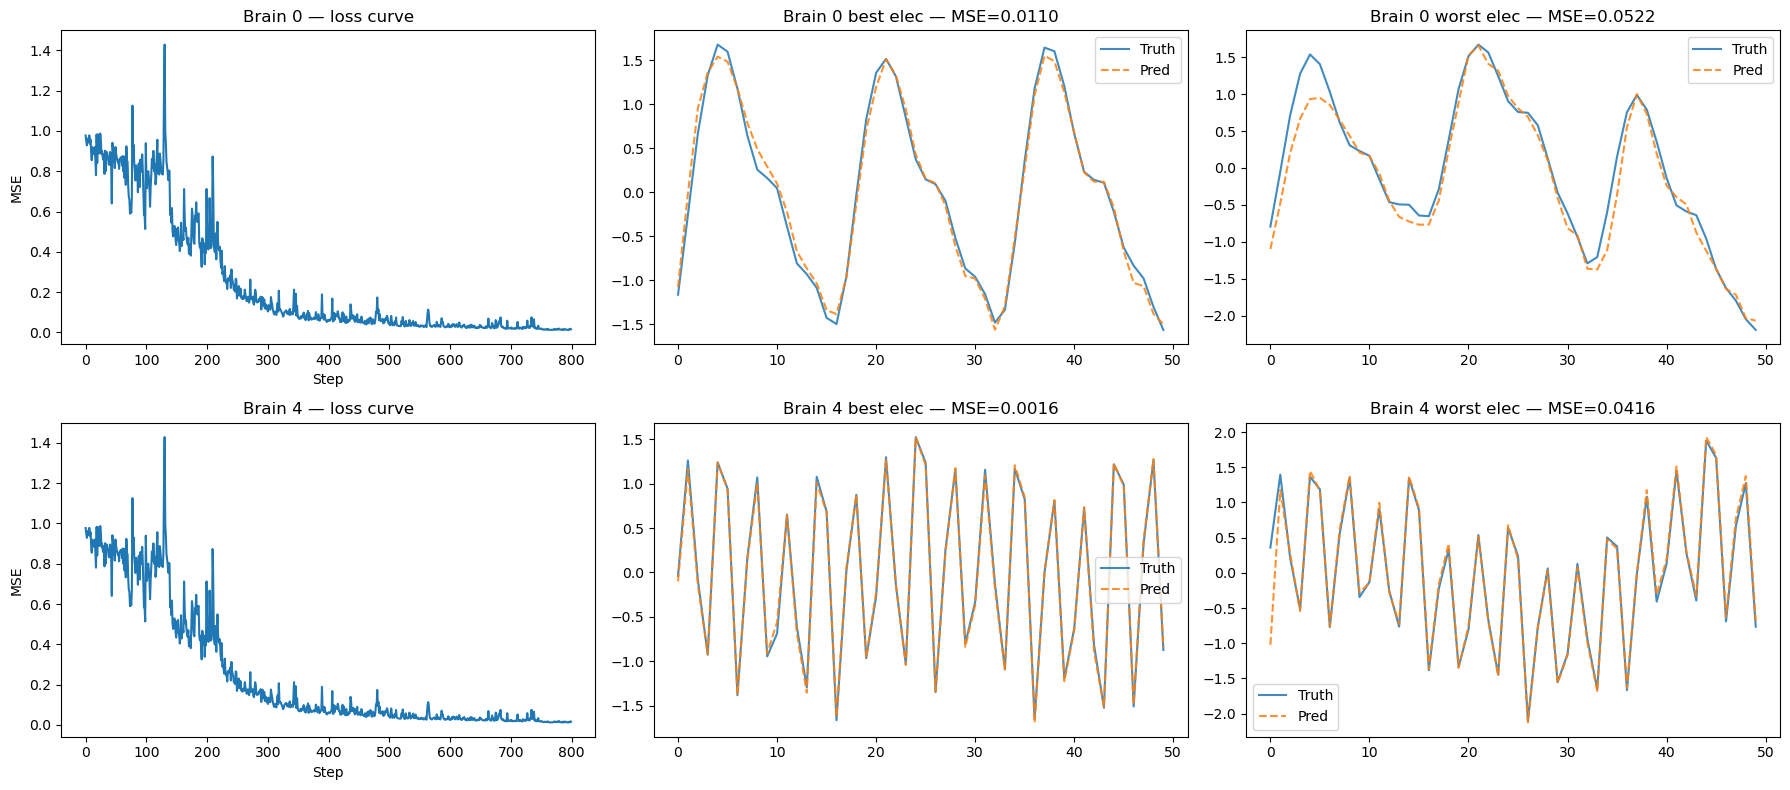

In [57]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn import Linear
from torch_geometric.utils import to_dense_adj
from sklearn.neighbors import NearestNeighbors

# ─── Config ───────────────────────────────────────────────────────────────────
win_size        = 50
k               = 10
max_per_patient = 12    # windows per brain
device = torch.device('cpu')
print(f"Using device: {device}")

# ─── DataLoader ───────────────────────────────────────────────────────────────
class DataLoader:
    def __init__(self, limit, patient, window_size, ecogs, desired_node_iters,
                 elecs_to_hold, xyz, k):
        self.limit              = limit
        self.current_total_iter = 0
        self.current_node_iter  = 0
        self.window_size        = window_size
        self.desired_node_iters = desired_node_iters
        self.ecog               = ecogs[patient]
        self.elecs_to_hold      = list(elecs_to_hold)
        self.xyz                = xyz
        self.num_nodes          = self.ecog.shape[1]

        if self.ecog.shape[0] < window_size * desired_node_iters:
            raise ValueError("Not enough data.")

        neighbors = NearestNeighbors(n_neighbors=k).fit(xyz)
        dists, idxs = neighbors.kneighbors(return_distance=True)
        all_edges, all_weights = [], []
        seen = set()
        for node, (nbrs, ds) in enumerate(zip(idxs, dists)):
            for nbr, d in zip(nbrs, ds):
                pair = (min(node, int(nbr)), max(node, int(nbr)))
                if pair not in seen:
                    seen.add(pair)
                    all_edges.append([node, int(nbr)])
                    all_weights.append(d)
        self.graph_edges   = np.array(all_edges)
        self.graph_weights = np.array(all_weights)

    def __iter__(self): return self

    def __next__(self):
        if self.current_total_iter >= self.limit: raise StopIteration
        if self.current_node_iter  >= self.desired_node_iters: raise StopIteration
        ws = self.current_node_iter * self.window_size
        we = ws + self.window_size
        node_features = []
        for i in range(self.num_nodes):
            if i in self.elecs_to_hold:
                node_features.append(np.zeros(self.window_size))
            else:
                node_features.append(self.ecog[ws:we, i])
        targets = np.array([self.ecog[ws:we, i] for i in self.elecs_to_hold])
        self.current_total_iter += 1
        self.current_node_iter  += 1
        return {"features": np.array(node_features), "edges": self.graph_edges,
                "weights": self.graph_weights, "target": targets,
                "locs": self.xyz, "elecs_held": self.elecs_to_hold}

# ─── Fixed DCRNN ──────────────────────────────────────────────────────────────
class FixedDConv(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K):
        super().__init__()
        self.K = K
        self.weight = torch.nn.Parameter(torch.FloatTensor(2, K, in_channels, out_channels))
        torch.nn.init.xavier_uniform_(self.weight[0])
        torch.nn.init.xavier_uniform_(self.weight[1])
        self.adj_out = None  # cached
        self.adj_in  = None

    def precompute_adj(self, edge_index, edge_weight, num_nodes, device):
        """Call once per unique graph before forward passes."""
        adj = to_dense_adj(edge_index.cpu(), edge_attr=edge_weight.cpu(),
                           max_num_nodes=num_nodes).squeeze(0)
        deg_out = adj.sum(dim=1).clamp(min=1)
        deg_in  = adj.sum(dim=0).clamp(min=1)
        self.adj_out = ((1.0 / deg_out).unsqueeze(1) * adj).to(device)
        self.adj_in  = (adj * (1.0 / deg_in).unsqueeze(0)).to(device)

    def forward(self, X, edge_index=None, edge_weight=None):
        Tx_0 = X
        H = (torch.matmul(Tx_0, self.weight[0][0]) +
             torch.matmul(Tx_0, self.weight[1][0]))
        if self.K > 1:
            Tx_1_o = torch.matmul(self.adj_out, X)
            Tx_1_i = torch.matmul(self.adj_in.T, X)
            H = H + torch.matmul(Tx_1_o, self.weight[0][1]) + \
                    torch.matmul(Tx_1_i, self.weight[1][1])
        for k in range(2, self.K):
            Tx_2_o = 2 * torch.matmul(self.adj_out, Tx_1_o) - Tx_0
            Tx_2_i = 2 * torch.matmul(self.adj_in.T, Tx_1_i) - Tx_0
            H = H + torch.matmul(Tx_2_o, self.weight[0][k]) + \
                    torch.matmul(Tx_2_i, self.weight[1][k])
            Tx_0, Tx_1_o, Tx_1_i = Tx_1_o, Tx_2_o, Tx_2_i
        return H

class FixedDCRNN(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K, dropout=0.3):
        super().__init__()
        self.out_channels = out_channels
        self.dropout = torch.nn.Dropout(dropout)
        self.conv_z = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_r = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_h = FixedDConv(in_channels + out_channels, out_channels, K)

    def forward(self, X, H=None):
        if H is None:
            H = torch.zeros(X.shape[0], self.out_channels, device=X.device)
        Z = torch.sigmoid(self.conv_z(torch.cat([X, H], dim=1)))
        R = torch.sigmoid(self.conv_r(torch.cat([X, H], dim=1)))
        H_tilde = torch.tanh(self.conv_h(torch.cat([X, R * H], dim=1)))
        h = (1 - Z) * H + Z * H_tilde
        return self.dropout(h)  # only active during model.train()

class DCRNNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, K=2):
        super().__init__()
        self.dcrnn_encoder_fwd = FixedDCRNN(in_channels,         hidden_channels, K)
        self.dcrnn_encoder_bwd = FixedDCRNN(in_channels,         hidden_channels, K)
        self.combine           = Linear(hidden_channels * 2,      hidden_channels)
        self.dcrnn_decoder     = FixedDCRNN(4,                    hidden_channels, K)
        self.lin               = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_weight, locs):
        T = x.shape[0]
        h_fwd = None
        for t in range(T):
            h_fwd = self.dcrnn_encoder_fwd(x[t], edge_index, edge_weight, H=h_fwd)
        h_bwd = None
        for t in reversed(range(T)):
            h_bwd = self.dcrnn_encoder_bwd(x[t], edge_index, edge_weight, H=h_bwd)
        h = torch.tanh(self.combine(torch.cat([h_fwd, h_bwd], dim=-1)))
        preds          = []
        decoder_signal = torch.zeros(x.shape[1], 1, device=x.device)
        for t in range(T):
            decoder_input = torch.cat([decoder_signal, locs], dim=-1)
            h             = self.dcrnn_decoder(decoder_input, edge_index, edge_weight, H=h)
            out           = self.lin(h)
            preds.append(out)
            decoder_signal = out
        return torch.stack(preds, dim=-1).squeeze(1)  # [N, T]

# ─── Tensorize helper ─────────────────────────────────────────────────────────
def tensorize_point(point, win_size, list_held):
    edges        = torch.tensor(point['edges'],    dtype=torch.long)
    edge_weights = torch.tensor(point['weights'],  dtype=torch.float32)
    features     = torch.tensor(point['features'], dtype=torch.float32)
    locs         = torch.tensor(point['locs'],     dtype=torch.float32)
    y            = torch.tensor(point['target'],   dtype=torch.float32)

    if edges.shape[0] != 2:
        edges = edges.T

    ew_min = edge_weights.min(); ew_max = edge_weights.max()
    edge_weights = 1.0 - (edge_weights - ew_min) / (ew_max - ew_min).clamp(min=1e-6)

    locs = (locs - locs.min(0).values) / (
        locs.max(0).values - locs.min(0).values).clamp(min=1e-6)

    visible = [i for i in range(features.shape[0]) if i not in list_held]
    for i in visible:
        m = features[i].mean()
        s = features[i].std().clamp(min=1e-6)
        features[i] = (features[i] - m) / s

    y = (y - y.mean(dim=1, keepdim=True)) / y.std(dim=1, keepdim=True).clamp(min=1e-6)

    x_signal      = features.T.unsqueeze(-1)
    locs_expanded = locs.unsqueeze(0).expand(win_size, -1, -1)
    x             = torch.cat([x_signal, locs_expanded], dim=-1)

    mask_token = torch.randn(len(list_held), win_size, 4) * 0.02
    for idx, elec in enumerate(list_held):
        x[:, elec, :] = mask_token[idx]

    return {'x': x, 'y': y, 'locs': locs,
            'edges': edges, 'edge_weights': edge_weights,
            'elecs_held': list_held}

# ─── Build points from 2 brains ───────────────────────────────────────────────
all_points = []
for pat_index in [0, 4]:
    pat_locs      = get_1_patient_locations(pat_index, ecogs_cleaned, xyz_clean)
    pat_num_nodes = ecogs_cleaned[pat_index].shape[1]
    desired_iter  = int(ecogs_cleaned[pat_index].shape[0] / win_size)
    list_held     = np.random.choice(pat_num_nodes, size=int(pat_num_nodes / 3), replace=False)

    loader = DataLoader(
        limit=max_per_patient, patient=pat_index, window_size=win_size,
        ecogs=ecogs_cleaned, desired_node_iters=desired_iter,
        elecs_to_hold=list_held, xyz=pat_locs, k=k,
    )
    for point in loader:
        all_points.append(tensorize_point(point, win_size, list_held))

print(f"Total windows: {len(all_points)} across 2 brains")

# ─── Model ────────────────────────────────────────────────────────────────────
model     = DCRNNModel(in_channels=4, hidden_channels=64, K=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=30, factor=0.7, min_lr=1e-4 
)

loss_func = torch.nn.MSELoss()

# ─── Overfit loop ─────────────────────────────────────────────────────────────
best_loss  = float('inf')
best_state = None
losses     = []

print("Overfitting …")
def set_adj_for_model(model, edge_index, edge_weight, num_nodes, device):
    """Call once per patient graph before training on that patient's windows."""
    for module in model.modules():
        if isinstance(module, FixedDConv):
            module.precompute_adj(edge_index, edge_weight, num_nodes, device)

# in build points, store num_nodes too
# then before training loop, after shuffle:

for step in range(800):
    random.shuffle(all_points)
    model.train()
    step_losses = []

    current_graph = None
    for point in all_points:
        # only recompute adj when graph changes (different patient)
        graph_key = point['edges'].shape
        if graph_key != current_graph:
            set_adj_for_model(model, point['edges'], point['edge_weights'],
                              point['x'].shape[1], device)
            current_graph = graph_key

        x            = point['x'].to(device)
        y            = point['y'].to(device)
        locs         = point['locs'].to(device)
        edges        = point['edges'].to(device)
        edge_weights = point['edge_weights'].to(device)
        elecs_held   = point['elecs_held']

        optimizer.zero_grad(set_to_none=True)
        y_pred = model(x, edges, edge_weights, locs)
        loss   = loss_func(y_pred[elecs_held], y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        step_losses.append(loss.item())

    mean_loss = np.mean(step_losses)
    losses.append(mean_loss)
    scheduler.step(mean_loss)

    if mean_loss < best_loss:
        best_loss  = mean_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if step % 30 == 0:
        print(f"  step {step:3d}: loss={mean_loss:.6f}  best={best_loss:.6f}  "
              f"lr={optimizer.param_groups[0]['lr']:.5f}")

print(f"\nBest loss: {best_loss:.6f}")

# ─── Eval on best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for brain_idx, pat_index in enumerate([0, 4]):
    pt = [p for p in all_points
          if p['x'].shape[1] == ecogs_cleaned[pat_index].shape[1]][0]

    # ← re-set adj for this patient's graph before forward pass
    set_adj_for_model(model, pt['edges'], pt['edge_weights'],
                      pt['x'].shape[1], device)

    with torch.no_grad():
        y_pred = model(pt['x'].to(device), pt['edges'].to(device),
                       pt['edge_weights'].to(device), pt['locs'].to(device))

    pred_np = y_pred[pt['elecs_held']].cpu().numpy()
    true_np = pt['y'].cpu().numpy()
    per_elec_mse = ((pred_np - true_np) ** 2).mean(axis=1)
    best_e  = per_elec_mse.argmin()
    worst_e = per_elec_mse.argmax()

    axes[brain_idx][0].plot(losses)
    axes[brain_idx][0].set_title(f'Brain {pat_index} — loss curve')
    axes[brain_idx][0].set_xlabel('Step'); axes[brain_idx][0].set_ylabel('MSE')

    axes[brain_idx][1].plot(true_np[best_e],  label='Truth', alpha=0.85)
    axes[brain_idx][1].plot(pred_np[best_e],  label='Pred',  alpha=0.85, linestyle='--')
    axes[brain_idx][1].set_title(f'Brain {pat_index} best elec — MSE={per_elec_mse[best_e]:.4f}')
    axes[brain_idx][1].legend()

    axes[brain_idx][2].plot(true_np[worst_e], label='Truth', alpha=0.85)
    axes[brain_idx][2].plot(pred_np[worst_e], label='Pred',  alpha=0.85, linestyle='--')
    axes[brain_idx][2].set_title(f'Brain {pat_index} worst elec — MSE={per_elec_mse[worst_e]:.4f}')
    axes[brain_idx][2].legend()

plt.tight_layout()
plt.show()

In [ ]:
all_patients = list(range(13))
np.random.seed(42)
np.random.shuffle(all_patients)

train_patients = all_patients[:9]
val_patients   = all_patients[9:11]
test_patients  = all_patients[11:]

print("Train:", train_patients)
print("Val:", val_patients)
print("Test:", test_patients)

def build_points(patient_list, max_per_patient):
    all_points = []

    for pat_index in patient_list:
        pat_locs      = get_1_patient_locations(pat_index, ecogs_cleaned, xyz_clean)
        pat_num_nodes = ecogs_cleaned[pat_index].shape[1]
        desired_iter  = int(ecogs_cleaned[pat_index].shape[0] / win_size)

        # FIX held electrodes per brain
        rng = np.random.RandomState(100 + pat_index)
        list_held = rng.choice(pat_num_nodes,
                               size=int(pat_num_nodes / 3),
                               replace=False)

        loader = DataLoader(
            limit=max_per_patient,
            patient=pat_index,
            window_size=win_size,
            ecogs=ecogs_cleaned,
            desired_node_iters=desired_iter,
            elecs_to_hold=list_held,
            xyz=pat_locs,
            k=k,
        )

        for point in loader:
            pt = tensorize_point(point, win_size, list_held)
            pt["pat_id"] = pat_index  # IMPORTANT
            all_points.append(pt)

    return all_points

train_points = build_points(train_patients, max_per_patient)
val_points   = build_points(val_patients,   max_per_patient)
test_points  = build_points(test_patients,  max_per_patient)

print(len(train_points), len(val_points), len(test_points))

Using device: cpu
Train: [11, 9, 0, 8, 5, 2, 1, 12, 4]
Val:   [7, 10]
Test:  [3, 6]
Points — train: 450, val: 100, test: 100
Precomputed adjacency for 13 patients.
Epoch   0 | train=0.9391  val=0.9654  best_val=0.9654  lr=0.00100
Epoch  10 | train=0.8683  val=0.9868  best_val=0.9563  lr=0.00100
Epoch  20 | train=0.8524  val=1.0127  best_val=0.9563  lr=0.00100
Early stopping at epoch 25


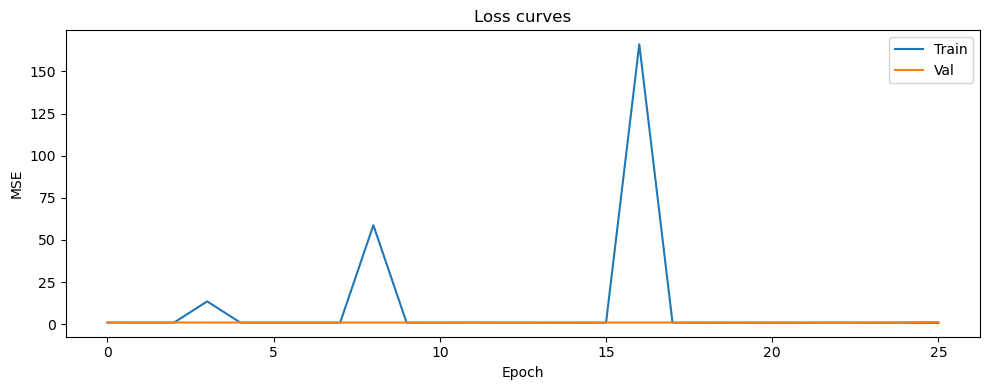

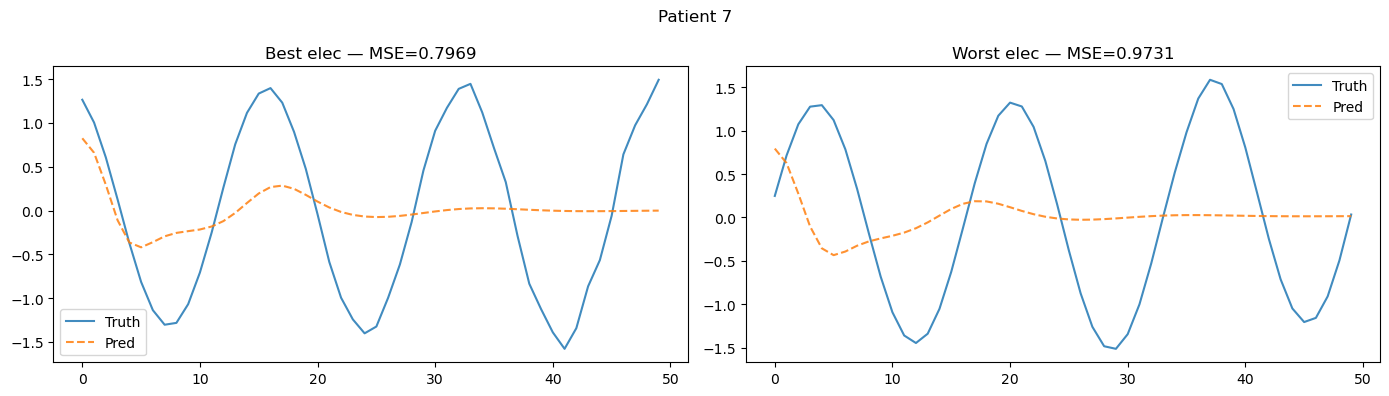

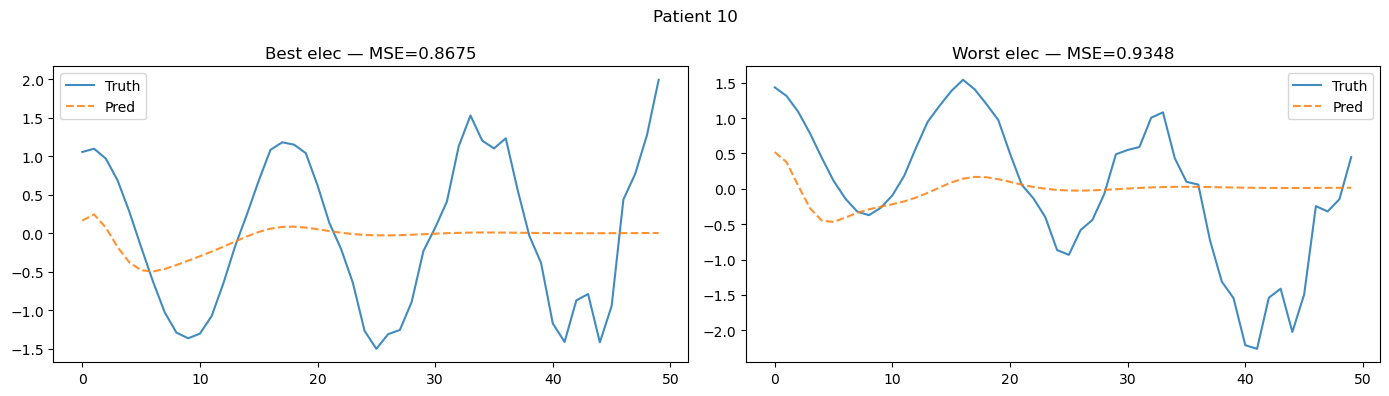

In [69]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn import Linear
from torch_geometric.utils import to_dense_adj
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

# ─── Config ───────────────────────────────────────────────────────────────────
win_size        = 50
k               = 10
max_per_patient = 50
device          = torch.device('cpu')
print(f"Using device: {device}")

# ─── DataLoader ───────────────────────────────────────────────────────────────
class DataLoader:
    def __init__(self, limit, patient, window_size, ecogs, desired_node_iters,
                 elecs_to_hold, xyz, k):
        self.limit              = limit
        self.current_total_iter = 0
        self.current_node_iter  = 0
        self.window_size        = window_size
        self.desired_node_iters = desired_node_iters
        self.ecog               = ecogs[patient]
        self.elecs_to_hold      = list(elecs_to_hold)
        self.xyz                = xyz
        self.num_nodes          = self.ecog.shape[1]

        if self.ecog.shape[0] < window_size * desired_node_iters:
            raise ValueError("Not enough data.")

        neighbors = NearestNeighbors(n_neighbors=k).fit(xyz)
        dists, idxs = neighbors.kneighbors(return_distance=True)
        all_edges, all_weights = [], []
        seen = set()
        for node, (nbrs, ds) in enumerate(zip(idxs, dists)):
            for nbr, d in zip(nbrs, ds):
                pair = (min(node, int(nbr)), max(node, int(nbr)))
                if pair not in seen:
                    seen.add(pair)
                    all_edges.append([node, int(nbr)])
                    all_weights.append(d)
        self.graph_edges   = np.array(all_edges)
        self.graph_weights = np.array(all_weights)

    def __iter__(self): return self

    def __next__(self):
        if self.current_total_iter >= self.limit: raise StopIteration
        if self.current_node_iter  >= self.desired_node_iters: raise StopIteration
        ws = self.current_node_iter * self.window_size
        we = ws + self.window_size
        node_features = []
        for i in range(self.num_nodes):
            if i in self.elecs_to_hold:
                node_features.append(np.zeros(self.window_size))
            else:
                node_features.append(self.ecog[ws:we, i])
        targets = np.array([self.ecog[ws:we, i] for i in self.elecs_to_hold])
        self.current_total_iter += 1
        self.current_node_iter  += 1
        return {"features": np.array(node_features), "edges": self.graph_edges,
                "weights": self.graph_weights, "target": targets,
                "locs": self.xyz, "elecs_held": self.elecs_to_hold}

# ─── Fixed DCRNN ──────────────────────────────────────────────────────────────
class FixedDConv(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K):
        super().__init__()
        self.K      = K
        self.weight = torch.nn.Parameter(
            torch.FloatTensor(2, K, in_channels, out_channels))
        torch.nn.init.xavier_uniform_(self.weight[0])
        torch.nn.init.xavier_uniform_(self.weight[1])
        self.adj_out = None
        self.adj_in  = None

    def set_adj(self, adj_out, adj_in):
        self.adj_out = adj_out
        self.adj_in  = adj_in

    def forward(self, X, edge_index=None, edge_weight=None):
        Tx_0 = X
        H = (torch.matmul(Tx_0, self.weight[0][0]) +
             torch.matmul(Tx_0, self.weight[1][0]))
        if self.K > 1:
            Tx_1_o = torch.matmul(self.adj_out, X)
            Tx_1_i = torch.matmul(self.adj_in.T, X)
            H = H + torch.matmul(Tx_1_o, self.weight[0][1]) + \
                    torch.matmul(Tx_1_i, self.weight[1][1])
        for k in range(2, self.K):
            Tx_2_o = 2 * torch.matmul(self.adj_out, Tx_1_o) - Tx_0
            Tx_2_i = 2 * torch.matmul(self.adj_in.T, Tx_1_i) - Tx_0
            H = H + torch.matmul(Tx_2_o, self.weight[0][k]) + \
                    torch.matmul(Tx_2_i, self.weight[1][k])
            Tx_0, Tx_1_o, Tx_1_i = Tx_1_o, Tx_2_o, Tx_2_i
        return H



class FixedDCRNN(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K, dropout=0.3):
        super().__init__()
        self.out_channels = out_channels
        self.dropout = torch.nn.Dropout(dropout)
        self.conv_z = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_r = FixedDConv(in_channels + out_channels, out_channels, K)
        self.conv_h = FixedDConv(in_channels + out_channels, out_channels, K)

    def set_adj(self, adj_out, adj_in):
        self.conv_z.set_adj(adj_out, adj_in)
        self.conv_r.set_adj(adj_out, adj_in)
        self.conv_h.set_adj(adj_out, adj_in)

    def forward(self, X, H=None):
        if H is None:
            H = torch.zeros(X.shape[0], self.out_channels, device=X.device)
        Z = torch.sigmoid(self.conv_z(torch.cat([X, H], dim=1)))
        R = torch.sigmoid(self.conv_r(torch.cat([X, H], dim=1)))
        H_tilde = torch.tanh(self.conv_h(torch.cat([X, R * H], dim=1)))
        h = (1 - Z) * H + Z * H_tilde
        return self.dropout(h)  # only active during model.train()


class DCRNNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, K=2):
        super().__init__()
        self.dcrnn_encoder_fwd = FixedDCRNN(in_channels,      hidden_channels,     K)
        self.dcrnn_encoder_bwd = FixedDCRNN(in_channels,      hidden_channels,     K)
        self.combine           = Linear(hidden_channels * 2,  hidden_channels)
        self.dcrnn_decoder     = FixedDCRNN(4,                hidden_channels,     K)
        self.lin               = Linear(hidden_channels, 1)

    def set_adj(self, adj_out, adj_in):
        self.dcrnn_encoder_fwd.set_adj(adj_out, adj_in)
        self.dcrnn_encoder_bwd.set_adj(adj_out, adj_in)
        self.dcrnn_decoder.set_adj(adj_out, adj_in)

    def forward(self, x, locs):
        T = x.shape[0]

        h_fwd = None
        for t in range(T):
            h_fwd = self.dcrnn_encoder_fwd(x[t], H=h_fwd)

        h_bwd = None
        for t in reversed(range(T)):
            h_bwd = self.dcrnn_encoder_bwd(x[t], H=h_bwd)

        h = torch.tanh(self.combine(torch.cat([h_fwd, h_bwd], dim=-1)))

        preds          = []
        decoder_signal = torch.zeros(x.shape[1], 1, device=x.device)
        for t in range(T):
            decoder_input = torch.cat([decoder_signal, locs], dim=-1)
            h             = self.dcrnn_decoder(decoder_input, H=h)
            out           = self.lin(h)
            preds.append(out)
            decoder_signal = out

        return torch.stack(preds, dim=-1).squeeze(1)  # [N, T]

# ─── Tensorize ────────────────────────────────────────────────────────────────
def tensorize_point(point, win_size, list_held):
    edges        = torch.tensor(point['edges'],    dtype=torch.long)
    edge_weights = torch.tensor(point['weights'],  dtype=torch.float32)
    features     = torch.tensor(point['features'], dtype=torch.float32)
    locs         = torch.tensor(point['locs'],     dtype=torch.float32)
    y            = torch.tensor(point['target'],   dtype=torch.float32)

    if edges.shape[0] != 2:
        edges = edges.T

    ew_min = edge_weights.min()
    ew_max = edge_weights.max()
    edge_weights = 1.0 - (edge_weights - ew_min) / (ew_max - ew_min).clamp(min=1e-6)

    locs = (locs - locs.min(0).values) / (
        locs.max(0).values - locs.min(0).values).clamp(min=1e-6)

    visible = [i for i in range(features.shape[0]) if i not in list_held]
    for i in visible:
        m = features[i].mean()
        s = features[i].std().clamp(min=1e-6)
        features[i] = (features[i] - m) / s

    y = (y - y.mean(dim=1, keepdim=True)) / y.std(dim=1, keepdim=True).clamp(min=1e-6)

    x_signal      = features.T.unsqueeze(-1)
    locs_expanded = locs.unsqueeze(0).expand(win_size, -1, -1)
    x             = torch.cat([x_signal, locs_expanded], dim=-1)

    mask_token = torch.randn(len(list_held), win_size, 4) * 0.02
    for idx, elec in enumerate(list_held):
        x[:, elec, :] = mask_token[idx]

    return {'x': x, 'y': y, 'locs': locs,
            'edges': edges, 'edge_weights': edge_weights,
            'elecs_held': list_held}

# ─── Build points ─────────────────────────────────────────────────────────────
def build_points(patient_list, max_per_patient):
    all_points = []
    for pat_index in patient_list:
        pat_locs      = get_1_patient_locations(pat_index, ecogs_cleaned, xyz_clean)
        pat_num_nodes = ecogs_cleaned[pat_index].shape[1]
        desired_iter  = int(ecogs_cleaned[pat_index].shape[0] / win_size)
        rng           = np.random.RandomState(100 + pat_index)
        list_held     = rng.choice(pat_num_nodes,
                                   size=int(pat_num_nodes / 3),
                                   replace=False).tolist()
        loader = DataLoader(
            limit=max_per_patient, patient=pat_index, window_size=win_size,
            ecogs=ecogs_cleaned, desired_node_iters=desired_iter,
            elecs_to_hold=list_held, xyz=pat_locs, k=k,
        )
        for point in loader:
            pt            = tensorize_point(point, win_size, list_held)
            pt["pat_id"]  = pat_index
            all_points.append(pt)
    return all_points

# ─── Patient split ────────────────────────────────────────────────────────────
all_patients = list(range(13))
np.random.seed(42)
np.random.shuffle(all_patients)
train_patients = all_patients[:9]
val_patients   = all_patients[9:11]
test_patients  = all_patients[11:]
print("Train:", train_patients)
print("Val:  ", val_patients)
print("Test: ", test_patients)

train_points = build_points(train_patients, max_per_patient)
val_points   = build_points(val_patients,   max_per_patient)
test_points  = build_points(test_patients,  max_per_patient)
print(f"Points — train: {len(train_points)}, val: {len(val_points)}, test: {len(test_points)}")

# ─── Precompute adjacency once per patient ────────────────────────────────────
def compute_adj_pair(edges, edge_weights, num_nodes, device):
    adj         = to_dense_adj(edges, edge_attr=edge_weights,
                               max_num_nodes=num_nodes).squeeze(0)
    deg_out_inv = 1.0 / adj.sum(dim=1).clamp(min=1)
    deg_in_inv  = 1.0 / adj.sum(dim=0).clamp(min=1)
    adj_out     = (deg_out_inv.unsqueeze(1) * adj).to(device)
    adj_in      = (adj * deg_in_inv.unsqueeze(0)).to(device)
    return adj_out, adj_in

adj_cache = {}
for point in train_points + val_points + test_points:
    pid = point['pat_id']
    if pid not in adj_cache:
        adj_cache[pid] = compute_adj_pair(
            point['edges'], point['edge_weights'],
            point['x'].shape[1], device
        )
    point['adj_out'], point['adj_in'] = adj_cache[pid]

print(f"Precomputed adjacency for {len(adj_cache)} patients.")

# ─── Model + optimiser ────────────────────────────────────────────────────────
model     = DCRNNModel(in_channels=4, hidden_channels=64, K=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=20, factor=0.7, min_lr=1e-4)
loss_func = torch.nn.MSELoss()

# ─── Training loop ────────────────────────────────────────────────────────────
best_val_loss      = float('inf')
best_state         = None
patience_counter   = 0
early_stop_patience = 20
train_losses_curve = []
val_losses_curve   = []

for epoch in range(100):
    # ── train ──
    random.shuffle(train_points)
    model.train()
    train_losses = []

    for point in train_points:
        model.set_adj(point['adj_out'], point['adj_in'])

        x          = point['x'].to(device)
        y          = point['y'].to(device)
        locs       = point['locs'].to(device)
        elecs_held = point['elecs_held']

        optimizer.zero_grad(set_to_none=True)
        y_pred = model(x, locs)
        loss   = loss_func(y_pred[elecs_held], y)

        if not torch.isfinite(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()
        train_losses.append(loss.item())

    train_loss = np.mean(train_losses) if train_losses else float('nan')
    train_losses_curve.append(train_loss)

    # ── validate ──
    model.eval()
    val_losses = []
    with torch.no_grad():
        for point in val_points:
            model.set_adj(point['adj_out'], point['adj_in'])
            y_pred = model(point['x'].to(device), point['locs'].to(device))
            loss   = loss_func(y_pred[point['elecs_held']], point['y'].to(device))
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses) if val_losses else float('nan')
    val_losses_curve.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}  "
              f"best_val={best_val_loss:.4f}  lr={optimizer.param_groups[0]['lr']:.5f}")

    if patience_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

# ─── Load best and evaluate ───────────────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()

# Loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses_curve, label='Train')
plt.plot(val_losses_curve,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Loss curves')
plt.legend(); plt.tight_layout(); plt.show()

# Per-patient prediction plots on val set
for pat_index in val_patients:
    pat_points = [p for p in val_points if p['pat_id'] == pat_index]
    if not pat_points:
        continue
    pt = pat_points[0]
    model.set_adj(pt['adj_out'], pt['adj_in'])

    with torch.no_grad():
        y_pred = model(pt['x'].to(device), pt['locs'].to(device))

    pred_np      = y_pred[pt['elecs_held']].cpu().numpy()
    true_np      = pt['y'].cpu().numpy()
    per_elec_mse = ((pred_np - true_np) ** 2).mean(axis=1)
    best_e       = per_elec_mse.argmin()
    worst_e      = per_elec_mse.argmax()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Patient {pat_index}')

    axes[0].plot(true_np[best_e],  label='Truth', alpha=0.85)
    axes[0].plot(pred_np[best_e],  label='Pred',  alpha=0.85, linestyle='--')
    axes[0].set_title(f'Best elec — MSE={per_elec_mse[best_e]:.4f}')
    axes[0].legend()

    axes[1].plot(true_np[worst_e], label='Truth', alpha=0.85)
    axes[1].plot(pred_np[worst_e], label='Pred',  alpha=0.85, linestyle='--')
    axes[1].set_title(f'Worst elec — MSE={per_elec_mse[worst_e]:.4f}')
    axes[1].legend()

    plt.tight_layout(); plt.show()

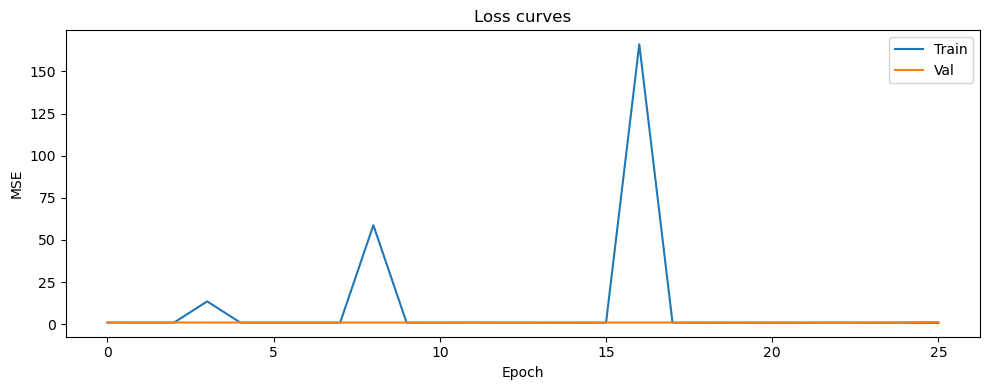

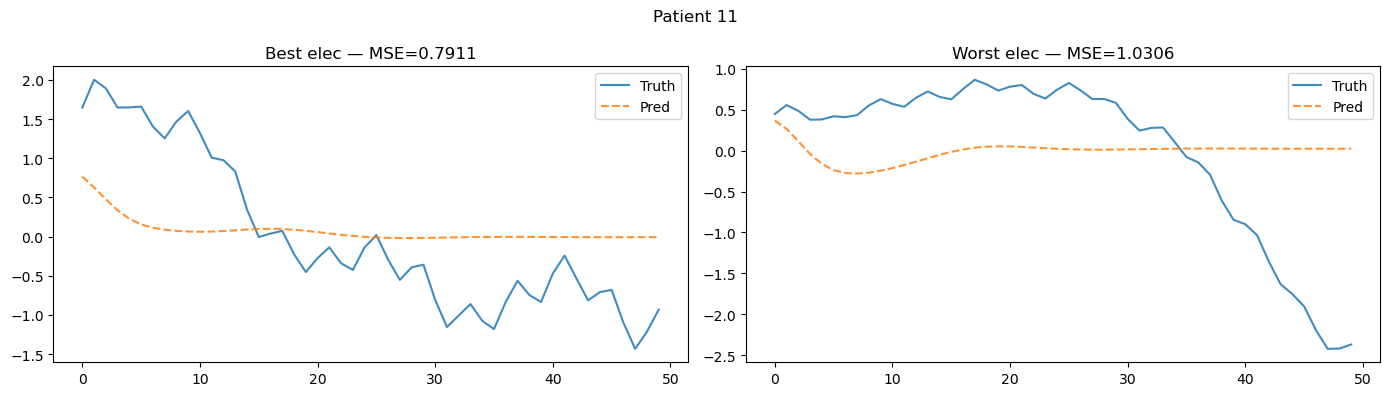

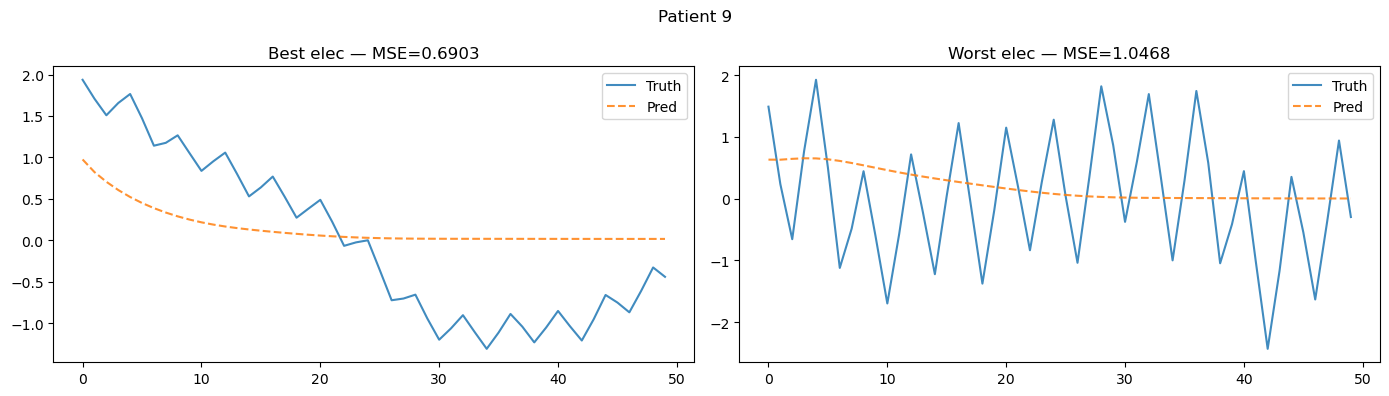

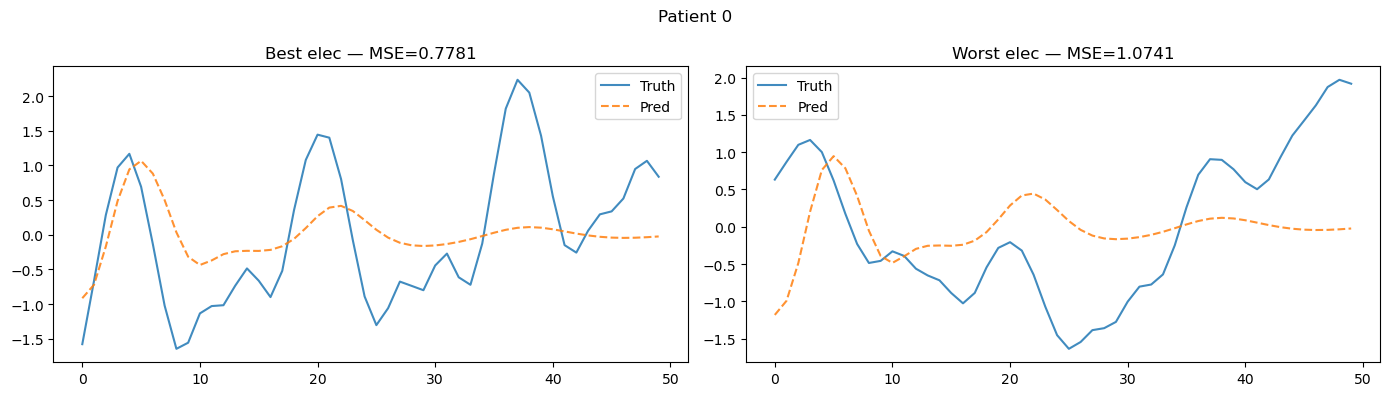

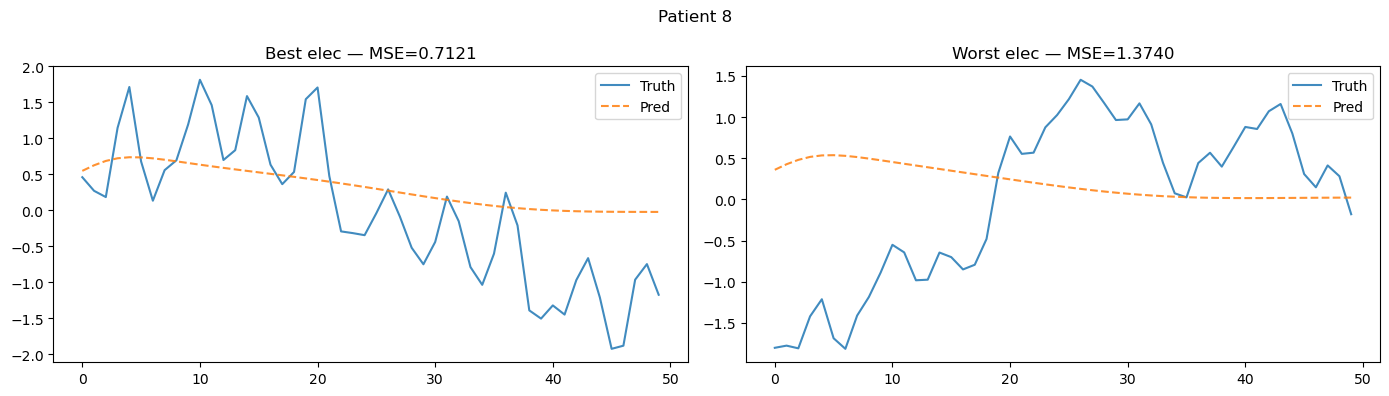

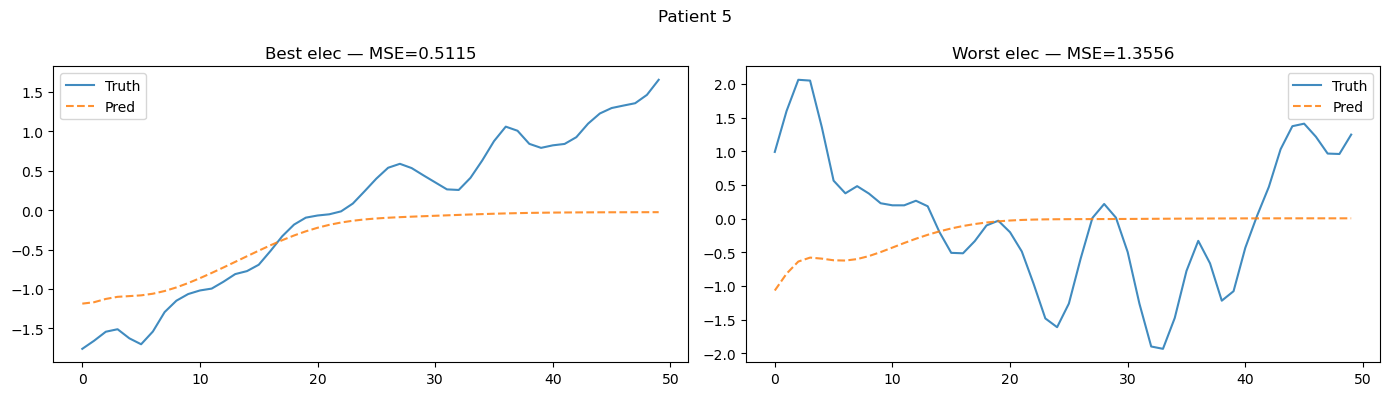

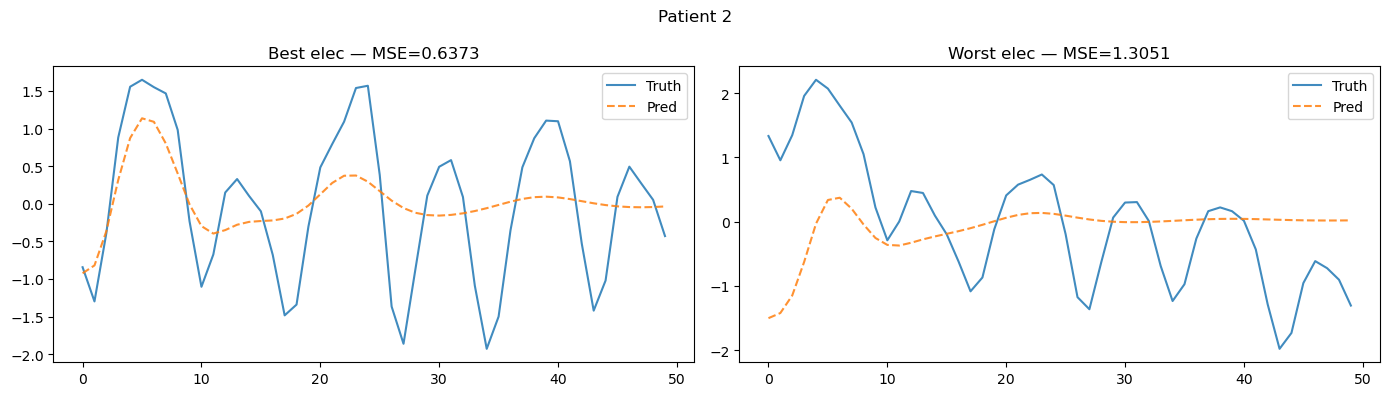

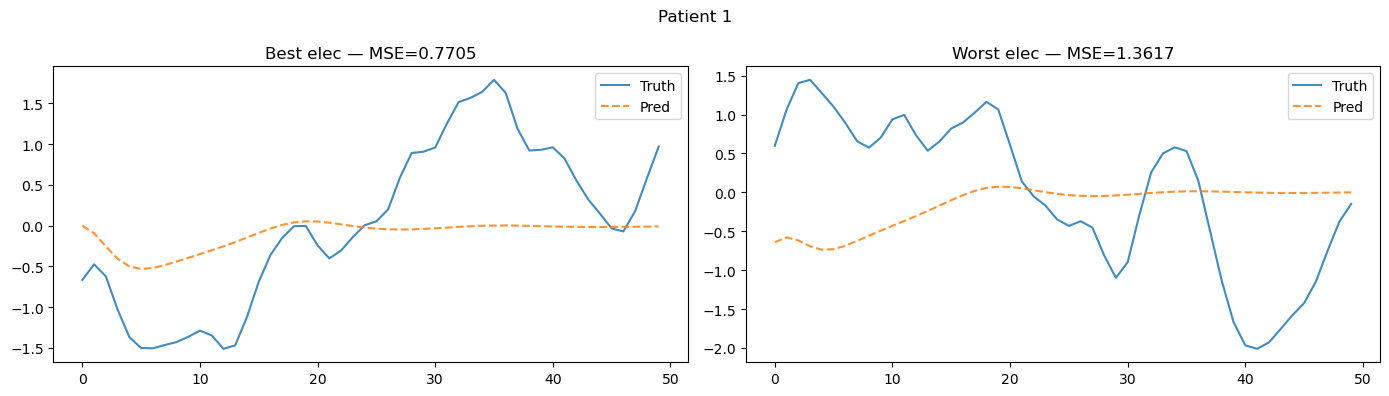

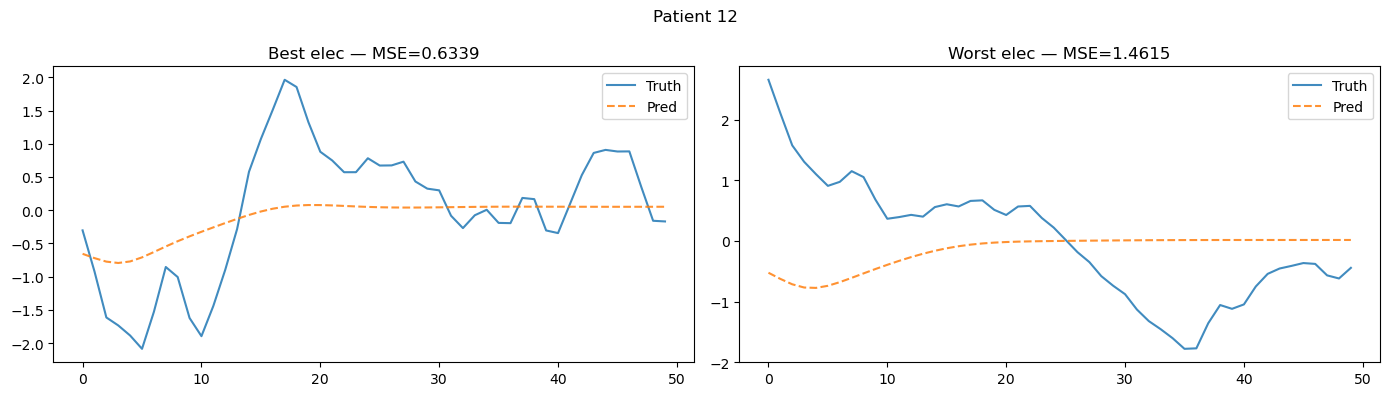

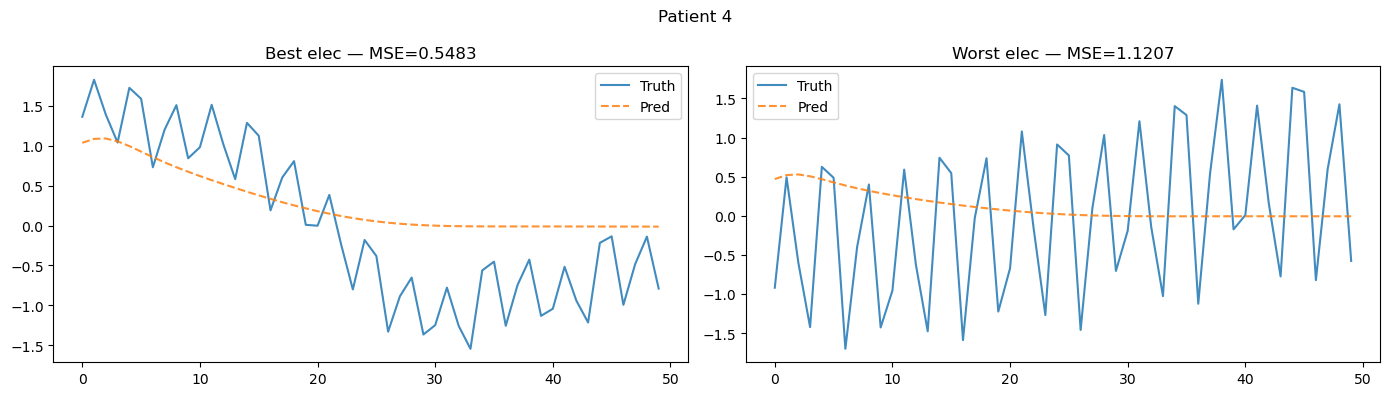

In [72]:
model.load_state_dict(best_state)
model.eval()

# Loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses_curve, label='Train')
plt.plot(val_losses_curve,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Loss curves')
plt.legend(); plt.tight_layout(); plt.show()


for pat_index in train_patients:
    pat_points = [p for p in train_points if p['pat_id'] == pat_index]
    if not pat_points:
        continue
    pt = pat_points[0]
    model.set_adj(pt['adj_out'], pt['adj_in'])

    with torch.no_grad():
        y_pred = model(pt['x'].to(device), pt['locs'].to(device))

    pred_np      = y_pred[pt['elecs_held']].cpu().numpy()
    true_np      = pt['y'].cpu().numpy()
    per_elec_mse = ((pred_np - true_np) ** 2).mean(axis=1)
    best_e       = per_elec_mse.argmin()
    worst_e      = per_elec_mse.argmax()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Patient {pat_index}')

    axes[0].plot(true_np[best_e],  label='Truth', alpha=0.85)
    axes[0].plot(pred_np[best_e],  label='Pred',  alpha=0.85, linestyle='--')
    axes[0].set_title(f'Best elec — MSE={per_elec_mse[best_e]:.4f}')
    axes[0].legend()

    axes[1].plot(true_np[worst_e], label='Truth', alpha=0.85)
    axes[1].plot(pred_np[worst_e], label='Pred',  alpha=0.85, linestyle='--')
    axes[1].set_title(f'Worst elec — MSE={per_elec_mse[worst_e]:.4f}')
    axes[1].legend()

    plt.tight_layout(); plt.show()